In [72]:
import pandas as pd
import numpy as np
import os

file_path = "datasets/madalena_processed_30min"

def feature_engineer(file_path):
    df = pd.read_csv(file_path)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed:')]    
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    df = df.sort_index()
    df['day_of_year'] = df.index.dayofyear
    df['season'] = df.index.month % 12 // 3
    df['month'] = df.index.month
    df['day_of_week'] = df.index.weekday
    df['hour'] = df.index.hour
    df['is_weekend'] = (df.index.weekday >= 5).astype(int)
    df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
    df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
    df['energy_diff'] = df['total_energy'].diff().fillna(method='bfill')
    df['max_energy'] = df['total_energy'].rolling(window=96).max().fillna(method='bfill')
    return df

In [73]:
import torch
from torch.utils.data import TensorDataset, DataLoader


def create_mimo_sequences(data, input_len=48, output_len=48):
    X, y = [], []
    for i in range(len(data) - input_len - output_len):
        X.append(data[i:i+input_len])
        y.append(data[i+input_len:i+input_len+output_len, 0]) 
    return np.array(X), np.array(y)

C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13688\3834234603.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_48'] = df['total_energy'].shift(48).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13688\3834234603.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_lag_1'] = df['total_energy'].shift(1).fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13688\3834234603.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['energy_diff'] = df['total_energy'].diff().fillna(method='bfill')
C:\Users\Kelsier\AppData\Local\Temp\ipykernel_13688\3834234603.py:22: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj

Epoch 1, Loss: 0.0164
Epoch 2, Loss: 0.0111
Epoch 3, Loss: 0.0108
Epoch 4, Loss: 0.0105
Epoch 5, Loss: 0.0103
Epoch 6, Loss: 0.0102
Epoch 7, Loss: 0.0100
Epoch 8, Loss: 0.0099
Epoch 9, Loss: 0.0097
Epoch 10, Loss: 0.0097
Epoch 11, Loss: 0.0096
Epoch 12, Loss: 0.0094
Epoch 13, Loss: 0.0094
Epoch 14, Loss: 0.0092
Epoch 15, Loss: 0.0090
Epoch 16, Loss: 0.0091
Epoch 17, Loss: 0.0090
Epoch 18, Loss: 0.0088
Epoch 19, Loss: 0.0086
Epoch 20, Loss: 0.0085
Epoch 21, Loss: 0.0084
Epoch 22, Loss: 0.0084
Epoch 23, Loss: 0.0083
Epoch 24, Loss: 0.0082
Epoch 25, Loss: 0.0081
Epoch 26, Loss: 0.0080
Epoch 27, Loss: 0.0079
Epoch 28, Loss: 0.0080
Epoch 29, Loss: 0.0078
Epoch 30, Loss: 0.0077
Epoch 31, Loss: 0.0077
Epoch 32, Loss: 0.0075
Epoch 33, Loss: 0.0075
Epoch 34, Loss: 0.0074
Epoch 35, Loss: 0.0076
Epoch 36, Loss: 0.0074
Epoch 37, Loss: 0.0073
Epoch 38, Loss: 0.0072
Epoch 39, Loss: 0.0072
Epoch 40, Loss: 0.0072
Epoch 41, Loss: 0.0071
Epoch 42, Loss: 0.0071
Epoch 43, Loss: 0.0070
Epoch 44, Loss: 0.00

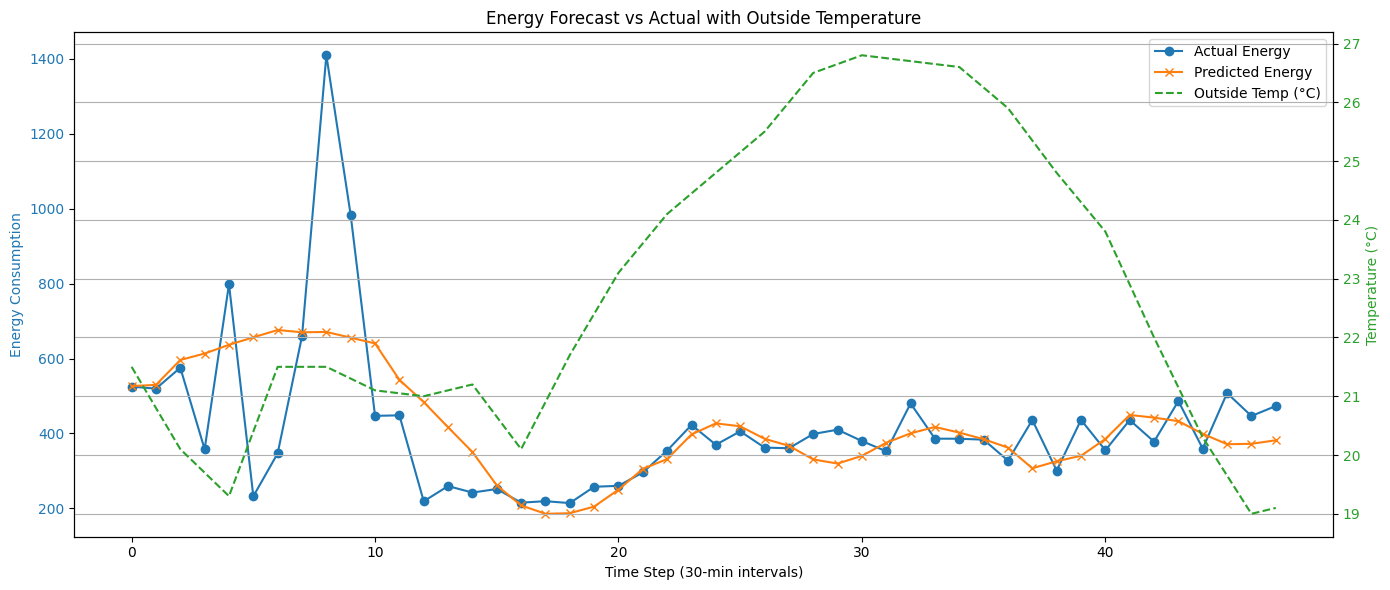

In [74]:
import torch.nn as nn
import matplotlib.pyplot as plt
import torch
import math
from sklearn.preprocessing import MinMaxScaler

def spike_weighted_mse(pred, target):
    time_weights = torch.linspace(0.5, 1.5, steps=target.shape[1]).to(pred.device)

    target_diff = torch.abs(target[:, 1:] - target[:, :-1])
    volatility = torch.cat([target_diff, target_diff[:, -1:]], dim=1)  

    weights = time_weights * (1.0 + volatility)

    loss = ((weights * (pred - target) ** 2)).mean()
    return loss

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)].to(x.device)
        return x

class CNNLSTM(nn.Module):
    def __init__(self, input_size, d_model=128, nhead=4, num_layers=2, output_len=48):
        super(CNNLSTM, self).__init__()
        self.cnn = nn.Conv1d(in_channels=input_size, out_channels=128, kernel_size=2, padding=1)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, output_len)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x = self.pos_encoder(x)
        x = self.transformer(x)  
        x = x[:, -1, :]        
        x = self.fc(x)    
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


for file in os.listdir(file_path):
    full_path = os.path.join(file_path, file)
    if file != 'E_147.csv':
        continue
    df = feature_engineer(full_path)
    features = ['total_energy', 'Tout', 'season',
                'month', 'day_of_week', 'hour', 'is_weekend', 'energy_diff', 'energy_lag_1', 'energy_lag_48', 'RH', 'max_energy']
    
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(df[features])
    df[features] = scaled_data
    data = df[features].values

    X, y = create_mimo_sequences(data)
    model = CNNLSTM(input_size=X.shape[2], d_model=128, output_len=48).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    dataset = TensorDataset(X_tensor, y_tensor)
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    for epoch in range(100):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = spike_weighted_mse(out, yb.to(device))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            preds = model(xb).cpu().numpy()
            all_preds.append(preds)
            all_targets.append(yb.numpy())

    preds = np.concatenate(all_preds, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    n_preds, n_steps = preds.shape
    n_features = len(features) 
    dummy = np.zeros((n_preds, n_steps, n_features - 1))
    preds_full = np.concatenate([preds[..., np.newaxis], dummy], axis=2) 
    targets_full = np.concatenate([targets[..., np.newaxis], dummy], axis=2)

    preds_flat = preds_full.reshape(-1, n_features)
    targets_flat = targets_full.reshape(-1, n_features)

    preds_inv = scaler.inverse_transform(preds_flat)[:, 0]   
    targets_inv = scaler.inverse_transform(targets_flat)[:, 0]

    preds = preds_inv.reshape(n_preds, n_steps)
    targets = targets_inv.reshape(n_preds, n_steps)

    mse = np.mean((preds - targets) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(preds - targets))

    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE:  {mae:.4f}")
    print(f"✅ MSE:  {mse:.4f}")
    sample_idx = 0  
    temperature_scaled = X_tensor[sample_idx, :, 1].numpy()
    dummy_temp = np.zeros((48, len(features)))
    dummy_temp[:, 1] = temperature_scaled 
    temp_inv = scaler.inverse_transform(dummy_temp)[:, 1]
    fig, ax1 = plt.subplots(figsize=(14, 6))
    steps = np.arange(48)

    ax1.plot(steps, targets[sample_idx], label="Actual Energy", marker='o', color='tab:blue')
    ax1.plot(steps, preds[sample_idx], label="Predicted Energy", marker='x', color='tab:orange')
    ax1.set_xlabel("Time Step (30-min intervals)")
    ax1.set_ylabel("Energy Consumption", color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.plot(steps, temp_inv, label="Outside Temp (°C)", color='tab:green', linestyle='--')
    ax2.set_ylabel("Temperature (°C)", color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')

    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper right')

    plt.title("Energy Forecast vs Actual with Outside Temperature")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    break


In [ ]:
# model.eval()
# latest_input = torch.tensor(X[-1:], dtype=torch.float32).to(device)
# with torch.no_grad():
#     forecast = model(latest_input).cpu().numpy().flatten()
